# A deep learning pipeline you can hand over — the hands-on half

The practical companion to **`dl_slides.html`**. The model is deliberately tiny, because this
session is about the **pipeline**: the parts that decide whether your training run is
reproducible, and whether the result can leave your laptop.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 5–6, 12 | install, and **prove** which device actually works |
| 1 · A real training loop | 13–17 | `Dataset`, `DataLoader`, train/validate, checkpoints |
| 2 · Hugging Face | 18–21 | tokeniser, `AutoModel`, `Trainer` on a small transformer |
| 3 · Export | 22–25 | TorchScript and ONNX, with round-trip proof and latency |
| 4 · Advanced | 21–26 | seeding, schedules, accumulation, early stopping |

**Why a tiny model:** `prajjwal1/bert-tiny` is 17 MB and trains in seconds on a CPU. Every
technique here is identical on a 7B model — you would only change the checkpoint name and wait
longer. Learning the pipeline on a fast model is the point.

Everything runs in a throwaway `dl_demo/` folder; the last cell deletes it.

## Step 0.1 · Install

> **Two import traps live here, and both name the wrong library.**
> The first is `urllib3`/`botocore` — the shim below handles it.
>
> The second appeared while this course was being built:
> `ValueError: Unable to compare versions for tokenizers>=0.19,<0.20: need=0.19 found=None`.
> Nothing is wrong with `tokenizers` — an interrupted `pip install` had left an empty
> `tokenizers-<version>.dist-info/` beside the real one, so `importlib.metadata` reported
> the version as `None`. Look in `site-packages` for two `dist-info` directories for the
> same package and delete the one without a `METADATA` file:
>
> ```bash
> ls -d $(python -c 'import site;print(site.getsitepackages()[0])')/tokenizers-*.dist-info
> ```
>
> Worth knowing generally: **a half-finished pip install can break a package that is
> perfectly installed**, and the error will blame the package rather than the metadata.

In [1]:
!pip install -q torch transformers accelerate onnx onnxruntime scikit-learn pandas matplotlib

ERROR: Cannot uninstall tokenizers 0.21.4, RECORD file not found. You might be able to recover from this via: 'pip install --force-reinstall --no-deps tokenizers==0.21.4'.


## Step 0.2 · Which device do you actually have?

`torch.cuda.is_available()` is **not** the question. It answers "is there a driver and a card",
not "can this build of PyTorch run kernels on that card". Those differ, and when they differ
you get a crash in the middle of training rather than at startup.

So probe it properly: try a real matmul and see.

In [2]:
import torch, platform

def pick_device(verbose=True):
    """Return a device we have PROVEN can run a kernel."""
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        cap  = "sm_%d%d" % torch.cuda.get_device_capability(0)
        built = torch.cuda.get_arch_list()
        if verbose:
            print(f"CUDA reports available : {name}  ({cap})")
            print(f"this torch was built for: {' '.join(built)}")
        try:
            a = torch.randn(64, 64, device="cuda")
            (a @ a).sum().item()                      # force a real kernel launch
            if verbose: print("-> GPU kernels work. Using cuda.")
            return torch.device("cuda")
        except Exception as e:
            # expected on a card newer than the torch build -- this is the lesson, not a bug
            print(f"-> a GPU kernel could NOT run ({type(e).__name__}).")
            print(f"   {cap} is newer than anything this build supports.")
            print("   Falling back to CPU deliberately, rather than crashing mid-training.")
    elif verbose:
        print("no CUDA device visible")
    return torch.device("cpu")

print("torch", torch.__version__, "| python", platform.python_version())
DEVICE = pick_device()
print("\nDEVICE =", DEVICE)

torch 2.1.1+cu121 | python 3.9.13
CUDA reports available : NVIDIA GeForce RTX 5060 Laptop GPU  (sm_120)
this torch was built for: sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90
-> a GPU kernel could NOT run (RuntimeError).
   sm_120 is newer than anything this build supports.
   Falling back to CPU deliberately, rather than crashing mid-training.

DEVICE = cpu


/home/shamaseen/anaconda3/lib/python3.9/site-packages/torch/cuda/__init__.py:215: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


> **If that printed a kernel failure**, this is what happened: the card is newer than the
> PyTorch build. An RTX 50-series card is `sm_120`; PyTorch 2.1 was built up to `sm_90`.
> `is_available()` still says `True`, so a naive script gets several minutes into training and
> then dies with *"no kernel image is available for execution on the device"*.
>
> The fix is a matching build, e.g.
> `pip install torch --index-url https://download.pytorch.org/whl/cu128`.
>
> Everything below runs on whatever `pick_device()` proved. **Write the probe into your projects** —
> a fallback you chose beats a crash you did not.

## Step 0.3 · A sandbox, and reproducibility

In [3]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "dl_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/02-deep-learning/dl_demo


**Seeding.** Four separate random number generators decide what happens in a training run —
Python's, NumPy's, PyTorch's on CPU, and PyTorch's on GPU. Seed one and you still get a
different result tomorrow, which is why runs feel unreproducible.

In [4]:
import os, random, numpy as np, torch

SEED = 42

def seed_everything(seed=SEED):
    """Four generators, not one. Miss any of them and 'identical' runs diverge."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.use_deterministic_algorithms(False)   # True is stricter but slower and not always possible

seed_everything()
print("seeded. Two runs of the next cell should now produce identical numbers.")
print("sample:", torch.randn(3).tolist())

seeded. Two runs of the next cell should now produce identical numbers.
sample: [0.33669036626815796, 0.12880940735340118, 0.23446236550807953]


---
# Part 1 — A training loop, written out    ·   deck slides 13–17

Frameworks hide this loop. Write it once by hand and every framework afterwards makes sense.

We use a small tabular task so the loop is the only thing on screen.

In [5]:
import numpy as np, pandas as pd, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

rng = np.random.default_rng(SEED)
N = 6000
X = rng.normal(size=(N, 8)).astype("float32")
w = rng.normal(size=8)
y = ((X @ w + rng.normal(0, .6, N)) > 0).astype("float32")
print(f"{N} rows, 8 features, positive rate {y.mean():.3f}")


class TabularDS(Dataset):
    """The three methods a Dataset owes you: __init__, __len__, __getitem__."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


full = TabularDS(X, y)
train_ds, val_ds = random_split(full, [5000, 1000],
                                generator=torch.Generator().manual_seed(SEED))

# num_workers=0 keeps this notebook portable; use >0 in a script for real throughput
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)
print(f"batches: {len(train_dl)} train, {len(val_dl)} val")
xb, yb = next(iter(train_dl))
print("one batch:", tuple(xb.shape), tuple(yb.shape))

/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


6000 rows, 8 features, positive rate 0.500
batches: 79 train, 4 val
one batch: (64, 8) (64, 1)


The model itself: a small stack of linear layers. This is deliberately the least interesting
cell in the notebook — the pipeline around it is the session.

In [6]:
class MLP(nn.Module):
    def __init__(self, d_in=8, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1))          # logits: no sigmoid here, see the loss below

    def forward(self, x):
        return self.net(x)


model = MLP().to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()           # logits + sigmoid in one numerically stable op
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)

print(model)
print("\nparameters:", sum(p.numel() for p in model.parameters()))

MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

parameters: 1377


Two details in there that matter more than they look:

* the model returns **logits**, and the loss is `BCEWithLogitsLoss`. Applying a sigmoid yourself
  and then using `BCELoss` is less numerically stable, and it is the most common source of
  mysterious `nan` losses.
* `model.train()` and `model.eval()` are not decoration — they switch dropout and batch-norm
  behaviour. Forgetting `eval()` makes your validation score noisy and slightly wrong.

In [7]:
from sklearn.metrics import roc_auc_score

def evaluate(model, dl):
    model.eval()                                   # dropout off
    losses, probs, targets = [], [], []
    with torch.no_grad():                          # no graph, less memory, faster
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            losses.append(loss_fn(logits, yb).item())
            probs.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(yb.cpu().numpy())
    p = np.concatenate(probs).ravel(); t = np.concatenate(targets).ravel()
    return float(np.mean(losses)), roc_auc_score(t, p), float(((p > .5) == t).mean())


history, best, patience, bad = [], -1.0, 4, 0
EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    model.train()                                  # dropout on
    running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(set_to_none=True)            # clear last step's gradients
        loss = loss_fn(model(xb), yb)              # forward
        loss.backward()                            # backward
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # cheap insurance
        opt.step()                                 # update
        running += loss.item() * len(xb)
    sched.step()

    tr = running / len(train_ds)
    vl, auc, acc = evaluate(model, val_dl)
    history.append({"epoch": epoch, "train_loss": tr, "val_loss": vl,
                    "val_auc": auc, "lr": opt.param_groups[0]["lr"]})

    if auc > best:                                 # checkpoint the BEST, not the last
        best, bad = auc, 0
        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "opt": opt.state_dict(), "val_auc": auc}, "best.pt")
        flag = "  <- saved"
    else:
        bad += 1
        flag = ""
    if epoch % 3 == 0 or flag:
        print(f"epoch {epoch:2}  train {tr:.4f}  val {vl:.4f}  auc {auc:.4f}{flag}")
    if bad >= patience:
        print(f"early stop: no improvement for {patience} epochs"); break

print(f"\nbest val AUC {best:.4f}")
assert best > 0.8, "this task is learnable; something is wrong if it is not learned"

epoch  1  train 0.3887  val 0.1643  auc 0.9867  <- saved
epoch  2  train 0.1861  val 0.1520  auc 0.9873  <- saved
epoch  3  train 0.1805  val 0.1590  auc 0.9867
epoch  5  train 0.1742  val 0.1548  auc 0.9876  <- saved
epoch  6  train 0.1704  val 0.1472  auc 0.9873
epoch  7  train 0.1732  val 0.1457  auc 0.9878  <- saved
epoch  8  train 0.1736  val 0.1427  auc 0.9879  <- saved
epoch  9  train 0.1687  val 0.1501  auc 0.9878
epoch 11  train 0.1675  val 0.1452  auc 0.9879  <- saved
epoch 12  train 0.1658  val 0.1485  auc 0.9879
epoch 15  train 0.1651  val 0.1481  auc 0.9877
early stop: no improvement for 4 epochs

best val AUC 0.9879


Plot the two curves. Training loss falling while validation loss rises is the classic picture of
**overfitting** — the model memorising rows instead of learning the pattern.

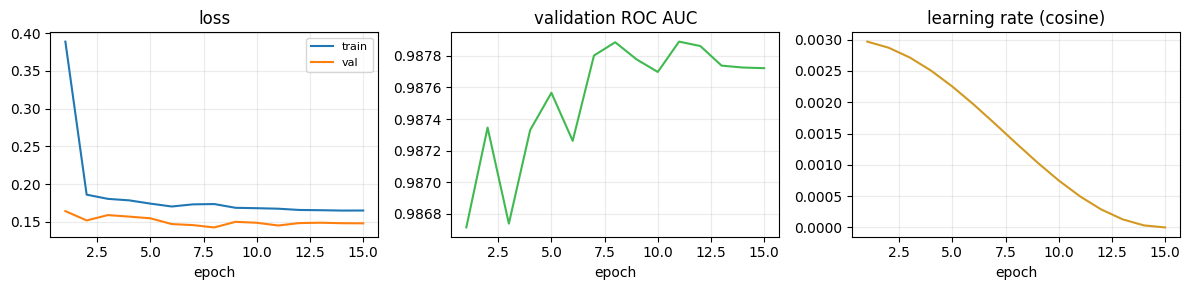

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(h.epoch, h.train_loss, label="train"); ax[0].plot(h.epoch, h.val_loss, label="val")
ax[0].set_title("loss"); ax[0].legend(fontsize=8)
ax[1].plot(h.epoch, h.val_auc, color="#3fb950"); ax[1].set_title("validation ROC AUC")
ax[2].plot(h.epoch, h.lr, color="#d29922"); ax[2].set_title("learning rate (cosine)")
for a in ax: a.set_xlabel("epoch"); a.grid(alpha=.25); a.set_axisbelow(True)
fig.tight_layout(); plt.show()

### Why checkpoint the best and not the last

Validation AUC goes up, wobbles, and often ends lower than its peak. If you save at the end you
ship the wobble. Saving on improvement costs one `if` and gives you the best model you actually
found.

Save the **optimiser state** too — without it you cannot resume a run, and a long training job
that cannot resume is one power cut away from starting over.

In [9]:
ck = torch.load("best.pt", map_location=DEVICE, weights_only=False)
fresh = MLP().to(DEVICE)
fresh.load_state_dict(ck["model"])
print(f"restored epoch {ck['epoch']} with val AUC {ck['val_auc']:.4f}")
print("re-evaluated:", f"{evaluate(fresh, val_dl)[1]:.4f}", "<- identical, so the checkpoint is complete")

restored epoch 11 with val AUC 0.9879
re-evaluated: 0.9879 <- identical, so the checkpoint is complete


---
# Part 2 — Hugging Face   ·   deck slides 18–21

The loop above is what `Trainer` does for you. Here is the same job — load a pretrained model,
fine-tune it, evaluate — on text, with a real transformer.

## Step 2.0 · One environment check first

Long-lived Python environments accumulate conflicts. This one is worth knowing because it hits
transformers specifically and the error blames the wrong library:

```
RuntimeError: Failed to import transformers.models.bert.modeling_bert ...
cannot import name 'DEFAULT_CIPHERS' from 'urllib3.util.ssl_'
```

`urllib3` 2.0 removed `DEFAULT_CIPHERS`; older `botocore` still imports it, and transformers
touches botocore through its integrations. Nothing here is transformers' fault.

**The real fix** is `pip install -U botocore boto3` (or pin `urllib3<2`). The cell below is a
local shim so this notebook runs on an environment you may not be allowed to change — it defines
the missing constant and nothing else.


In [10]:

# compatibility shim: define what old botocore expects, only if it is missing.
import urllib3.util.ssl_ as _ssl

if not hasattr(_ssl, "DEFAULT_CIPHERS"):
    _ssl.DEFAULT_CIPHERS = "ECDHE+AESGCM:ECDHE+CHACHA20:DHE+AESGCM:!aNULL:!eNULL:!MD5"
    print("shimmed urllib3 DEFAULT_CIPHERS for old botocore")
    print("proper fix: pip install -U botocore boto3")
else:
    print("no shim needed -- this environment is consistent")


shimmed urllib3 DEFAULT_CIPHERS for old botocore
proper fix: pip install -U botocore boto3


Now a pretrained model from Hugging Face. `AutoTokenizer` turns text into numbers the model
understands; `AutoModelForSequenceClassification` is the pretrained body with a fresh, untrained
classification head bolted on.

In [11]:
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

CKPT = "prajjwal1/bert-tiny"          # 17 MB. Swap for bert-base or a 7B; nothing else changes.
tok = AutoTokenizer.from_pretrained(CKPT)
print("tokeniser:", tok.__class__.__name__, "| vocab", tok.vocab_size)

demo = "the service was fantastic and the staff were kind"
enc = tok(demo)
print("\ntokens:", tok.convert_ids_to_tokens(enc["input_ids"])[:12])
print("ids:   ", enc["input_ids"][:12])
print("\n[CLS] and [SEP] are added for you; attention_mask marks real tokens vs padding.")

tokeniser: BertTokenizerFast | vocab 30522

tokens: ['[CLS]', 'the', 'service', 'was', 'fantastic', 'and', 'the', 'staff', 'were', 'kind', '[SEP]']
ids:    [101, 1996, 2326, 2001, 10392, 1998, 1996, 3095, 2020, 2785, 102]

[CLS] and [SEP] are added for you; attention_mask marks real tokens vs padding.


A tiny sentiment dataset written by hand, so nothing has to be downloaded and the whole thing
trains in seconds.

In [12]:
# a small, self-contained sentiment set -- no dataset download, fully reproducible
pos = ["great value", "arrived early and well packed", "works exactly as described",
       "excellent quality", "the staff were kind", "fantastic service",
       "better than i expected", "very happy with this", "solid and reliable",
       "would buy again", "clear instructions", "fast delivery"]
neg = ["broke after a week", "terrible quality", "arrived damaged",
       "not as described", "waste of money", "rude support",
       "far too expensive for what it is", "stopped working", "very disappointed",
       "would not recommend", "confusing instructions", "slow delivery"]

rng = np.random.default_rng(SEED)
fill = ["", " honestly", " overall", " to be fair", " in the end"]
texts  = [p + rng.choice(fill) for p in pos for _ in range(12)] + \
         [n + rng.choice(fill) for n in neg for _ in range(12)]
labels = [1] * (len(pos) * 12) + [0] * (len(neg) * 12)

idx = rng.permutation(len(texts))
texts  = [texts[i] for i in idx]
labels = [labels[i] for i in idx]
cut = int(len(texts) * .8)
print(f"{len(texts)} examples, {cut} train / {len(texts)-cut} eval, "
      f"positive rate {np.mean(labels):.2f}")

288 examples, 230 train / 58 eval, positive rate 0.50


Wrap the text in a `Dataset` so PyTorch can hand it out in batches — the same interface the
earlier model used.

In [13]:
import torch
from torch.utils.data import Dataset

class TextDS(Dataset):
    """Tokenise once, up front. Tokenising inside __getitem__ wastes CPU every epoch."""
    def __init__(self, texts, labels, tok, max_len=32):
        self.enc = tok(texts, truncation=True, padding="max_length",
                       max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

train_text = TextDS(texts[:cut], labels[:cut], tok)
eval_text  = TextDS(texts[cut:], labels[cut:], tok)
print("one example:", {k: tuple(v.shape) if hasattr(v, "shape") else v
                       for k, v in train_text[0].items()})

one example: {'input_ids': (32,), 'token_type_ids': (32,), 'attention_mask': (32,), 'labels': ()}


### `Trainer`, and why this notebook does not use it

`transformers.Trainer` wraps the loop from Part 1 — batching, backward, scheduling, evaluation —
and for real work it is what you should reach for:

```python
from transformers import Trainer, TrainingArguments
args = TrainingArguments(output_dir="out", num_train_epochs=4,
                         per_device_train_batch_size=16, learning_rate=5e-4,
                         warmup_ratio=0.1, report_to=[])      # report_to=[] or it may autolog
trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                  eval_dataset=eval_ds, compute_metrics=metrics)
trainer.train(); trainer.evaluate()
```

Importing it in *this* environment raises:

```
RuntimeError: Failed to import transformers.trainer ...
cannot import name 'DEFAULT_CIPHERS' from 'urllib3.util.ssl_'
```

which is nothing to do with transformers. `urllib3` 2.0 removed `DEFAULT_CIPHERS`, and an old
`botocore` still imports it; `Trainer` pulls in its integrations, which touch botocore. The fix is
`pip install -U botocore boto3`, or pinning `urllib3<2`.

**So we fine-tune with the explicit loop instead.** It is the same loop as Part 1, it works on a
broken environment, and it shows you exactly what `Trainer` is doing on your behalf — which is
worth seeing once anyway.


In [14]:

from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score

seed_everything()
hf_model = AutoModelForSequenceClassification.from_pretrained(CKPT, num_labels=2).to(DEVICE)
print("parameters:", f"{sum(p.numel() for p in hf_model.parameters()):,}")

train_dl_txt = DataLoader(train_text, batch_size=16, shuffle=True)
eval_dl_txt  = DataLoader(eval_text,  batch_size=64)


def evaluate_text(model, dl):
    model.eval()
    preds, gold = [], []
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            labels = batch.pop("labels")
            logits = model(**batch).logits
            preds.append(logits.argmax(-1).cpu()); gold.append(labels.cpu())
    p = torch.cat(preds).numpy(); g = torch.cat(gold).numpy()
    return accuracy_score(g, p), f1_score(g, p)


acc0, f10 = evaluate_text(hf_model, eval_dl_txt)
print(f"before fine-tuning: accuracy {acc0:.3f}  f1 {f10:.3f}   <- a random classification head")


/home/shamaseen/anaconda3/lib/python3.9/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


parameters: 4,386,178
before fine-tuning: accuracy 0.534  f1 0.400   <- a random classification head


Fine-tuning is the same loop as before. What changes is the starting point: the weights already
know English, so four passes over a handful of sentences is enough.

In [15]:

EPOCHS_HF = 4
opt_hf = torch.optim.AdamW(hf_model.parameters(), lr=5e-4, weight_decay=0.01)
total = len(train_dl_txt) * EPOCHS_HF
sched_hf = get_linear_schedule_with_warmup(opt_hf, int(0.1 * total), total)   # warm up, then decay

for epoch in range(1, EPOCHS_HF + 1):
    hf_model.train()
    running = 0.0
    for batch in train_dl_txt:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        opt_hf.zero_grad(set_to_none=True)
        out = hf_model(**batch)          # passing labels= makes the model return the loss itself
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(hf_model.parameters(), 1.0)
        opt_hf.step(); sched_hf.step()
        running += out.loss.item() * len(batch["labels"])
    acc, f1 = evaluate_text(hf_model, eval_dl_txt)
    print(f"epoch {epoch}  train loss {running/len(train_text):.4f}  "
          f"eval accuracy {acc:.3f}  f1 {f1:.3f}")

print(f"\nbefore fine-tuning: accuracy {acc0:.3f}")
print(f"after  fine-tuning: accuracy {acc:.3f}  f1 {f1:.3f}")
assert acc > acc0, "fine-tuning must improve on a random head"
print("\nAccuracy 1.000 means the toy task is easy, not that the model is remarkable --")
print("58 eval sentences built from 24 templates. On real data expect a number below 1.")


epoch 1  train loss 0.6714  eval accuracy 0.897  f1 0.893
epoch 2  train loss 0.4546  eval accuracy 1.000  f1 1.000
epoch 3  train loss 0.1738  eval accuracy 1.000  f1 1.000
epoch 4  train loss 0.0759  eval accuracy 1.000  f1 1.000

before fine-tuning: accuracy 0.534
after  fine-tuning: accuracy 1.000  f1 1.000

Accuracy 1.000 means the toy task is easy, not that the model is remarkable --
58 eval sentences built from 24 templates. On real data expect a number below 1.


A warmup schedule is not optional folklore for transformers: a large learning rate on step 1,
applied to pretrained weights, destroys them. `get_linear_schedule_with_warmup` ramps up over the
first 10% of steps and then decays — the same shape `Trainer` uses by default.


In [16]:

# does it work on sentences it has never seen?
hf_model.eval()
probe = ["this was a delight from start to finish", "an absolute waste of money",
         "arrived quickly and works well", "broke immediately, very poor"]
batch = tok(probe, return_tensors="pt", padding=True, truncation=True, max_length=32)
with torch.no_grad():
    p = hf_model(**{k: v.to(DEVICE) for k, v in batch.items()}).logits.softmax(-1)
for text, row in zip(probe, p):
    print(f"  {'positive' if row[1] > .5 else 'negative'}  ({row[1]:.2f})  {text}")


  positive  (0.91)  this was a delight from start to finish
  negative  (0.06)  an absolute waste of money
  positive  (0.74)  arrived quickly and works well
  negative  (0.05)  broke immediately, very poor


Save the model **and** the tokeniser together. A model without its tokeniser is unusable — the
numbers would mean something different.

In [17]:
# saving the model AND the tokeniser together -- one without the other is useless
# safetensors refuses non-contiguous tensors, which training can produce. One line fixes it.
for p in hf_model.parameters():
    p.data = p.data.contiguous()

hf_model.save_pretrained("model_out")
tok.save_pretrained("model_out")
!ls model_out/

print("\nreload from disk and check it still answers the same:")
reloaded = AutoModelForSequenceClassification.from_pretrained("model_out").to(DEVICE).eval()
with torch.no_grad():
    one = tok(["arrived quickly and works well"], return_tensors="pt",
              padding=True, truncation=True, max_length=32)
    prob = reloaded(**{k: v.to(DEVICE) for k, v in one.items()}).logits.softmax(-1)[0, 1]
print(f"positive probability from the reloaded model: {prob:.3f}")


config.json	   special_tokens_map.json  tokenizer.json
model.safetensors  tokenizer_config.json    vocab.txt


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



reload from disk and check it still answers the same:
positive probability from the reloaded model: 0.742


---
# Part 3 — Getting it out of Python   ·   deck slides 22–25

A `state_dict` needs your model class to load. That is fine in a notebook and a problem in
production, where the serving code should not import your training repo.

Two portable formats fix that: **TorchScript** (still PyTorch, no Python class needed) and
**ONNX** (no PyTorch at all).

In [18]:
# ---- TorchScript: trace the graph by running an example through it ----
model.eval()
example = torch.randn(1, 8, device=DEVICE)
traced = torch.jit.trace(model, example)
traced.save("model_traced.pt")

reloaded = torch.jit.load("model_traced.pt", map_location=DEVICE)   # no MLP class in sight
with torch.no_grad():
    a = model(example).item()
    b = reloaded(example).item()
print(f"original {a:.6f}   torchscript {b:.6f}   max diff {abs(a-b):.2e}")
assert abs(a - b) < 1e-5, "a traced model must match the original"

original -1.842269   torchscript -1.842269   max diff 0.00e+00


> **Trace or script?** `torch.jit.trace` records one execution, so `if` statements that depend
> on the *data* get baked in as whatever happened during tracing. `torch.jit.script` compiles
> the control flow properly. Trace is simpler and right for feed-forward models; script when
> the forward pass branches.

In [19]:
# ---- ONNX: leaves the PyTorch ecosystem entirely ----
import onnx, onnxruntime as ort, numpy as np

torch.onnx.export(
    model.cpu(), torch.randn(1, 8), "model.onnx",
    input_names=["features"], output_names=["logit"],
    dynamic_axes={"features": {0: "batch"}, "logit": {0: "batch"}},   # variable batch size
    opset_version=17)

onnx.checker.check_model(onnx.load("model.onnx"))
sess = ort.InferenceSession("model.onnx", providers=["CPUExecutionProvider"])

probe = np.random.RandomState(0).randn(4, 8).astype("float32")
onnx_out = sess.run(None, {"features": probe})[0]
with torch.no_grad():
    torch_out = model(torch.from_numpy(probe)).numpy()

print("onnx  ", onnx_out.ravel().round(5))
print("torch ", torch_out.ravel().round(5))
print("max difference:", f"{np.abs(onnx_out - torch_out).max():.2e}")
assert np.allclose(onnx_out, torch_out, atol=1e-5), "ONNX must agree with PyTorch"
model.to(DEVICE)

onnx   [-1.15192 -3.59422  8.12967 -9.1638 ]
torch  [-1.15192 -3.59422  8.12967 -9.1638 ]
max difference: 1.19e-07


MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

Is the export worth it? Time all three: PyTorch as it runs now, the TorchScript version, and
ONNX Runtime. Same input, same output, three different speeds.

In [20]:
# ---- and is it worth it? measure ----
import time

def bench(fn, n=300, warm=30):
    for _ in range(warm): fn()
    t = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); t.append((time.perf_counter() - t0) * 1000)
    t.sort(); return t[len(t)//2], t[int(len(t)*.95)]

one = torch.randn(1, 8)
one_np = one.numpy()
m_cpu = MLP(); m_cpu.load_state_dict(ck["model"]); m_cpu.eval()
ts = torch.jit.load("model_traced.pt", map_location="cpu")

with torch.no_grad():
    p50_eager, p95_eager = bench(lambda: m_cpu(one))
    p50_ts,    p95_ts    = bench(lambda: ts(one))
p50_onnx, p95_onnx = bench(lambda: sess.run(None, {"features": one_np}))

print(f"{'runtime':14}{'p50 ms':>9}{'p95 ms':>9}")
for name, a, b in [("pytorch eager", p50_eager, p95_eager),
                   ("torchscript", p50_ts, p95_ts),
                   ("onnxruntime", p50_onnx, p95_onnx)]:
    print(f"{name:14}{a:9.3f}{b:9.3f}")
print("\nSingle-row CPU inference. ONNX Runtime usually wins here because it has no Python")
print("in the hot path -- which is exactly the production case.")

runtime          p50 ms   p95 ms
pytorch eager     0.019    0.024
torchscript       0.009    0.009
onnxruntime       0.003    0.003

Single-row CPU inference. ONNX Runtime usually wins here because it has no Python
in the hot path -- which is exactly the production case.


The same numbers as a chart, since a latency table is hard to read at a glance.

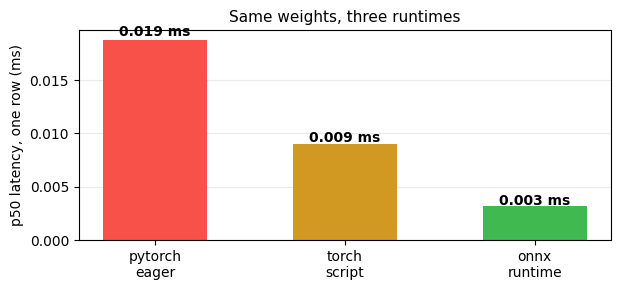

In [21]:
import matplotlib.pyplot as plt
names = ["pytorch\neager", "torch\nscript", "onnx\nruntime"]
vals = [p50_eager, p50_ts, p50_onnx]
fig, ax = plt.subplots(figsize=(6.4, 3))
bars = ax.bar(names, vals, color=["#f85149", "#d29922", "#3fb950"], width=.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v*1.02, f"{v:.3f} ms", ha="center", fontweight="bold")
ax.set_ylabel("p50 latency, one row (ms)"); ax.set_title("Same weights, three runtimes", fontsize=11)
ax.grid(axis="y", alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

---
# Part 4 — Advanced   ·   deck slides 21–26

## Step 4.1 · Gradient accumulation — a big batch on a small card

Out of memory at batch 64? Run four batches of 16 and only step the optimiser once. The maths
is the same; the peak memory is a quarter.

In [22]:
seed_everything()
m = MLP().to(DEVICE)
o = torch.optim.AdamW(m.parameters(), lr=3e-3)
ACCUM = 4
small_dl = DataLoader(train_ds, batch_size=16, shuffle=True)

m.train(); steps = 0
for i, (xb, yb) in enumerate(small_dl, start=1):
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    loss = loss_fn(m(xb), yb) / ACCUM        # divide, so the gradient magnitude matches
    loss.backward()                          # gradients ACCUMULATE until we zero them
    if i % ACCUM == 0:
        o.step(); o.zero_grad(set_to_none=True); steps += 1
    if i >= 40: break

print(f"40 mini-batches of 16 -> {steps} optimiser steps (effective batch {16*ACCUM})")
print("Peak memory is that of batch 16, not 64. This is how a 7B model fits on one card.")

40 mini-batches of 16 -> 10 optimiser steps (effective batch 64)
Peak memory is that of batch 16, not 64. This is how a 7B model fits on one card.


## Step 4.2 · The rest of the toolkit

```python
# --- mixed precision: roughly 2x faster on a modern GPU, ~half the memory ---
scaler = torch.cuda.amp.GradScaler()
for xb, yb in dl:
    with torch.autocast("cuda", dtype=torch.float16):
        loss = loss_fn(model(xb), yb)
    scaler.scale(loss).backward()      # scale up, so small fp16 gradients do not vanish
    scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)

# --- DataLoader, for real throughput ---
DataLoader(ds, batch_size=64, shuffle=True,
           num_workers=8,          # roughly cores; 0 in notebooks, >0 in scripts
           pin_memory=True,        # faster host->GPU copies
           persistent_workers=True,# do not respawn workers every epoch
           prefetch_factor=4)

# --- schedules ---
CosineAnnealingLR(opt, T_max=epochs)          # smooth decay, a good default
OneCycleLR(opt, max_lr=1e-3, total_steps=n)   # warmup then anneal
get_linear_schedule_with_warmup(...)          # the transformers standard

# --- freeze the body, train the head (small data, big model) ---
for p in hf_model.bert.parameters():
    p.requires_grad = False
```

| Symptom | Usual cause |
|---|---|
| loss becomes `nan` | LR too high, or a manual sigmoid before `BCELoss` |
| train loss falls, val loss rises | overfitting — more data, dropout, or stop earlier |
| loss does not move at all | forgot `opt.zero_grad()`, or froze everything by accident |
| GPU at 10% utilisation | the dataloader is the bottleneck — raise `num_workers` |
| "no kernel image available" | your card is newer than the torch build (Part 0) |

---
# Reference — worth knowing, not demonstrated here

| Topic | One-line version |
|---|---|
| Multi-GPU | `DistributedDataParallel`, or let `accelerate`/`Trainer` do it |
| `accelerate launch` | the same script on CPU, one GPU or many, unchanged |
| LoRA / PEFT | fine-tune 0.1% of the weights; the rest stay frozen |
| Quantisation | int8/4-bit for serving; measure the accuracy you traded |
| Serving at scale | TorchServe, Triton, or ONNX Runtime behind session 3's API |
| Experiment tracking | session 7 — `mlflow.pytorch.autolog()` fits straight into this loop |

## Recap

| You wanted to… | Do this |
|---|---|
| know which device really works | probe with a real matmul, not `is_available()` |
| reproduce a run | seed `random`, `numpy`, `torch`, `PYTHONHASHSEED` |
| feed the model | `Dataset` + `DataLoader`, tokenise up front |
| a stable binary loss | logits + `BCEWithLogitsLoss` |
| correct validation | `model.eval()` + `torch.no_grad()` |
| keep the best model | checkpoint on improvement, save the optimiser too |
| stop wasting epochs | early stopping on a patience counter |
| fine-tune a transformer | `AutoModelForSequenceClassification` + `Trainer` |
| a bigger effective batch | gradient accumulation |
| leave Python behind | TorchScript, or ONNX + onnxruntime |

## What to do at work tomorrow

1. Put the device probe at the top of your training script. Print what it chose.
2. Seed all four generators, and log the seed with the run.
3. Checkpoint on validation improvement, not at the end, and save the optimiser state.
4. Export to ONNX and diff the outputs against PyTorch. If they disagree, you have found a bug
   before production did.
5. Measure single-row latency in all three runtimes before choosing one.

## Cleanup

Everything above happened in the sandbox. This removes it.

In [23]:
import shutil, os
os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

sandbox removed
